# Dataset Preparation 

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [13]:
df = pd.read_csv("usnd_Cleaned.csv")

In [14]:
print(df.columns)

Index(['Declaration Number', 'Declaration Type', 'Declaration Date', 'State',
       'County', 'Incident type', 'Disaster Title', 'Start Date', 'End Date',
       'Close Date', 'Individual Assistance Program',
       'Individuals & Households Program', 'Public Assistance Program',
       'Hazard Mitigation Program', 'year', 'month'],
      dtype='object')


In [15]:
df = df.rename(columns={
    'Incident type': 'incidentType',
    'State': 'state',
    'Individual Assistance Program': 'ihProgramDeclared',
    'Public Assistance Program': 'paProgramDeclared'
})

Firstly we import the required library for analysis then we load the dataset as the requirment of the milestone 4 and we have to checked the columns name then we used df.column

# Incident Type Distribution Analysis

In [16]:
incident_counts = df['incidentType'].value_counts()
print(incident_counts)

Storm              16250
Flood               9317
Hurricane           8764
Snow                3565
Fire                2647
Ice                 1970
Tornado             1412
Drought             1292
Winter               301
Other                297
Typhoon              119
Earthquake           105
Volcano               50
Water                 42
Chemical              18
Mud/Landslide         10
Tsunami                9
Dam/Levee Break        6
Human Cause            6
Terrorism              5
Name: incidentType, dtype: int64


<AxesSubplot:title={'center':'Disaster Type Distribution'}>

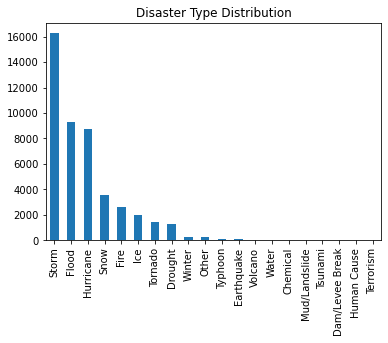

In [17]:
incident_counts.plot(kind='bar', title="Disaster Type Distribution")

Storms, floods, and hurricanes are the most frequent disasters, showing that weather-related events dominate, while rare disasters like tsunamis and terrorism occur very less.

# State vs Incident Type

In [18]:
state_incident = df.groupby(['state', 'incidentType']).size().unstack().fillna(0)

<AxesSubplot:xlabel='state'>

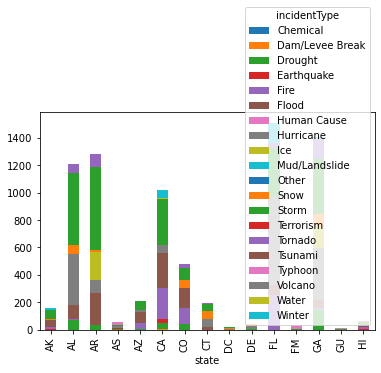

In [19]:
state_incident.head(15).plot(kind='bar', stacked=True)

<AxesSubplot:xlabel='incidentType', ylabel='state'>

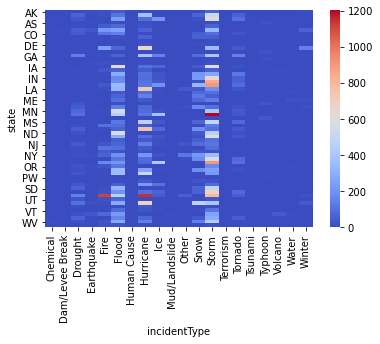

In [20]:
import seaborn as sns
sns.heatmap(state_incident, cmap='coolwarm')

Different states experience different disaster types, with some states being more disaster-prone. Coastal areas face more storms, while inland regions experience floods and tornadoes

# Disaster Assistance Program Analysis

In [21]:
df['ihProgramDeclared'] = df['ihProgramDeclared'].map({'Yes': 1, 'No': 0})
df['paProgramDeclared'] = df['paProgramDeclared'].map({'Yes': 1, 'No': 0})

In [22]:
assistance = df.groupby('incidentType')[['ihProgramDeclared', 'paProgramDeclared']].sum()

<AxesSubplot:xlabel='incidentType'>

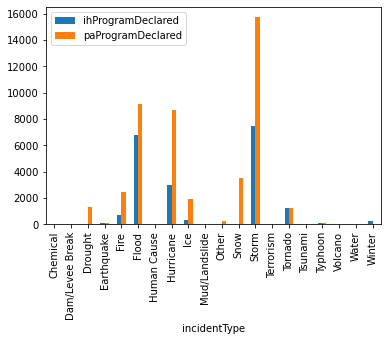

In [23]:
assistance.plot(kind='bar')

Most disaster types, especially storms, floods, and hurricanes, trigger both individual (IH) and public (PA) assistance programs frequently, indicating their high impact on people and infrastructure. Public assistance is generally used more often, showing greater damage to public facilities compared to individual losses.